### Lectre images 

0 => niveau de gris 

-1 => RGB 

nothing => read the imgs as it is originally 

img.shape => format 

img.shape[0]    => height

img.shape[1]    => width

img.shape[2]    => channels (RGB)

img.size        => total number of pixels (height x width x channels)

**cv2.waitKey():**Cette fonction sert à :

    -garder la fenêtre OpenCV ouverte
    -attendre une touche du clavier

Sans elle, l’image peut s’ouvrir puis se fermer immédiatement, et les événements clavier ne fonctionneront pas correctement.

**cv2.destroyAllWindows()**:Cette fonction sert à :

    -fermer proprement toutes les fenêtres OpenCV
    -libérer les ressources utilisées par les fenêtres

Sans elle, certaines fenêtres peuvent rester bloquées ou provoquer des problèmes d’affichage/mémoire.


In [ ]:
#Lecture imgs : 
import cv2 
img = cv2.imread('name.png')

#show imgs : 
cv2.imshow('name',img)
cv2.waitKey(0) # attendre un temps sp´ecifi´ejusqu’`a ce que nous rencontrions un ´ev´enement clavier.
cv2.destroyAllWindows() # fermer toutes les fenˆetres OpenCV.
cv2.waitKey(n) #if you don’t press anything → it continues automatically after time is over 

## Affichage des image en utilisant matplotlib :

In [ ]:
import cv2 
import matplotlib.pyplot as plt
M = cv2.imread('name.png')
if M is not None:
    M = cv2.cvtColor(M, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
    plt.imshow(M)
    plt.axis('off')  # Hide axes
    plt.show()

## Sauvegarde d img dans opencv 


In [ ]:
J = cv2.imread('name.png')
cv2.imwrite('name.jpg', J)

## La conversion de espaces de couleur 

 BGR est le format par défaut dans OpenCV.
BGR -> Gray : cv2.COLOR_BGR2GRAY

BGR -> RGB : cv2.COLOR_BGR2RGB

BGR -> HSV :cv2.COLOR_BGR2HSV   

HSV : (Hue, Saturation, Value) couleur + intensité + luminosité séparées

In [ ]:
cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

## Application de bruit:

In [ ]:
#appliquer le bruit :
from skimage.util import random_noise
random_noise(image , mode='poisson' , seed= None,clip=True, **kwargs)


## Histogramme :

In [ ]:
#cv2.calcHist(images, channels, mask ,histsize , ranges)
img = cv2.imread('name.png')
plt.imshow(img)
plt.show()
hist = cv2.calcHist([img], [1], None, [256], [0, 256])
plt.plot(hist)
plt.show()

## Histogram cumule :
hist_cum= hist.cumsum()
plt.plot(hist_cum)
plt.show()

# Equalisation d’histogramme :
equ = cv2.equalizeHist(img) #!!! uniquement sur les images de niveaux de gris 
hist_equ = cv2.calcHist([equ], [0], None, [256], [0, 256])
plt.plot(hist_equ)

## Brillance + convolution

In [ ]:
kernel = np.ones((5,5),np.float32)/25
blur = cv2.filter2D(img,-1,kernel)  
# -1 :c’est la profondeur (type) de l’image de sortie.
#garder le même type que l’image d’entrée”
plt.imshow(blur)
plt.show()

#

## les Flous :


eps = 0.4823529411764706


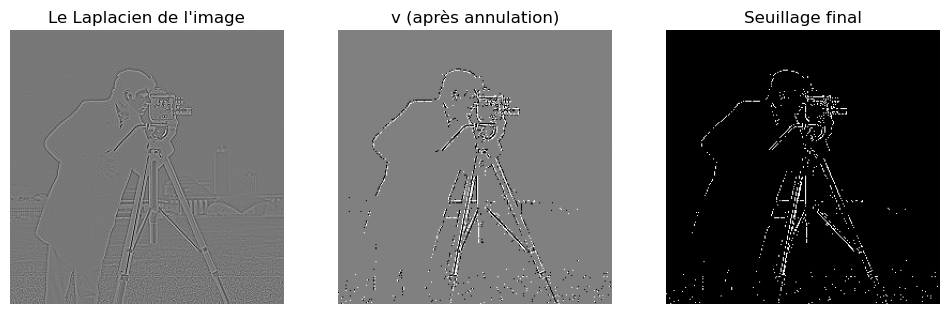

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Chargement (comme imread en MATLAB)
u = cv2.imread('cameraman.tif', cv2.IMREAD_GRAYSCALE)
u = u.astype(np.float64) / 255.0  # im2double

# 2. Taille
M, N = u.shape

# 3. Masque Laplacien
D = np.array([[0, 1, 0],
              [1, -4, 1],
              [0, 1, 0]], dtype=np.float64)

# 4. Filtre Laplacien (comme imfilter avec 'replicate')
Du = cv2.filter2D(u, -1, D, borderType=cv2.BORDER_REPLICATE)

# 5. Copie de v
v = Du.copy()

# 6. Calcul du seuil eps (graythresh en MATLAB)
# Convertir en uint8 pour Otsu
Du_uint8 = (Du * 255).astype(np.uint8)
eps = cv2.threshold(Du_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0] / 255.0

print(f"eps = {eps}")

# 7. Seuillage par annulation du Laplacien (version corrigée)
for i in range(M):
    for j in range(N):
        if Du[i, j] > eps:
            v[i, j] = 1
        elif Du[i, j] < -eps:
            v[i, j] = -1
        else:  # -eps <= Du[i,j] <= eps
            v[i, j] = 0

# 8. Second seuillage Otsu sur v
# Convertir v de [-1,0,1] vers [0,255]
v_uint8 = ((v + 1) / 2 * 255).astype(np.uint8)
seuil = cv2.threshold(v_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0] / 255.0

# 9. Seuillage final
Su = (v > seuil).astype(np.uint8)

# 10. Affichage
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(Du, cmap='gray')
plt.title('Le Laplacien de l\'image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(v, cmap='gray')
plt.title('v (après annulation)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Su, cmap='gray')
plt.title('Seuillage final')
plt.axis('off')

plt.show()